# 🧠 Foundation Models for Computer Vision

This workshop covers **four modern foundation models** applied to the same
COCO val2017 image subset — no task-specific training required.

| Part | Model | Task | CPU-friendly? |
|:----:|:-----:|:----:|:-------------:|
| 1 | **Depth Anything v2 Tiny** | Monocular depth estimation | ✅ |
| 2 | **DINOv3-Small** | Feature extraction → auto-segmentation | ✅ |
| 3 | **Grounding DINO** | Open-vocabulary detection (text→boxes) | ✅ slow |
| 4 | **MobileSAM** | Prompted segmentation (boxes→masks) | ✅ |
| 5 | **CLIP ViT-B/32** | Class verification + image retrieval | ✅ |
| 6 | **Full pipeline** | Grounding DINO → MobileSAM → CLIP | ✅ |
| 7 | **Kaggle submission** | Object retrieval Recall@K | — |

### Why foundation models?
> "Train once on internet-scale data, deploy everywhere without labels."

All models in this workshop are **frozen** — we never update their weights.
We only feed them images (and sometimes text prompts) and use their outputs.

```
Classical CV:   hand-crafted features → task-specific classifier
DL (supervised): labeled dataset → trained network
Foundation model: giant pre-training → zero-shot / few-shot on any task  ← today
```


---
## 📦 Part 0. Installation & Imports

In [ ]:
# Install all dependencies (run once)
%pip install -q transformers timm ultralytics open-clip-torch
%pip install -q pycocotools requests tqdm matplotlib


In [1]:
import os, json, time, requests, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn.functional as F
import torchvision.transforms as T

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cpu
PyTorch: 2.11.0+cpu


---
## 🗂️ Part 0b. Dataset — COCO val2017 (500 images)

We download 500 images from COCO val2017 and keep their annotations
(bounding boxes + category names). This single subset is reused across
all parts of the workshop.


In [2]:
DATA_DIR  = Path("coco_subset")
IMG_DIR   = DATA_DIR / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ANN_DIR = DATA_DIR / "annotations"

# Download annotations if needed
if not (ANN_DIR / "instances_val2017.json").exists():
    import zipfile, urllib.request
    zip_path = DATA_DIR / "annotations.zip"
    print("Downloading COCO annotations (~240 MB) …")
    urllib.request.urlretrieve(ANN_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    zip_path.unlink()
    print("✅ Annotations extracted")
else:
    print("✅ Annotations already present")

with open(ANN_DIR / "instances_val2017.json") as f:
    coco = json.load(f)

# Build lookup tables
id2name   = {c["id"]: c["name"] for c in coco["categories"]}
img_meta  = {img["id"]: img for img in coco["images"]}

# Group annotations by image
from collections import defaultdict
ann_by_img = defaultdict(list)
for ann in coco["annotations"]:
    ann_by_img[ann["image_id"]].append(ann)

# Take first 500 images
SUBSET_IDS = [img["id"] for img in coco["images"][:500]]
print(f"Subset: {len(SUBSET_IDS)} images")
print(f"Categories: {len(id2name)}")


✅ Annotations extracted
Subset: 500 images
Categories: 80


In [3]:
def download_image(img_id, dest_dir, timeout=10):
    """Download one COCO val image if not already present."""
    meta = img_meta[img_id]
    dst  = Path(dest_dir) / meta["file_name"]
    if not dst.exists():
        url = f"http://images.cocodataset.org/val2017/{meta['file_name']}"
        try:
            r = requests.get(url, timeout=timeout)
            dst.write_bytes(r.content)
        except Exception as e:
            return None
    return dst

# Download subset (skip if already done)
already = len(list(IMG_DIR.glob("*.jpg")))
if already < len(SUBSET_IDS):
    print(f"Downloading {len(SUBSET_IDS) - already} images …")
    for iid in tqdm(SUBSET_IDS):
        download_image(iid, IMG_DIR)
    print("✅ Download complete")
else:
    print(f"✅ {already} images already present")

img_paths = sorted(IMG_DIR.glob("*.jpg"))
print(f"Total images on disk: {len(img_paths)}")


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Download complete
Total images on disk: 493


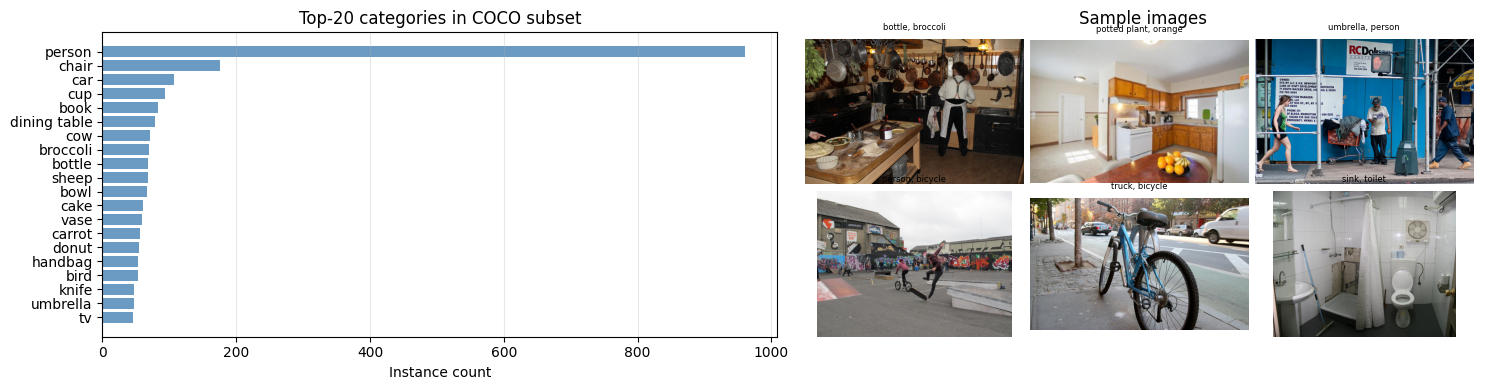

In [4]:
# ── Quick EDA ─────────────────────────────────────────────────────────────────
from collections import Counter

cat_counts = Counter()
for iid in SUBSET_IDS:
    for ann in ann_by_img[iid]:
        cat_counts[id2name[ann["category_id"]]] += 1

top20 = cat_counts.most_common(20)
names, counts = zip(*top20)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].barh(names[::-1], counts[::-1], color="steelblue", alpha=0.8)
axes[0].set_title("Top-20 categories in COCO subset")
axes[0].set_xlabel("Instance count")
axes[0].grid(axis="x", alpha=0.3)

# Show 6 sample images
sample_ids = SUBSET_IDS[:6]
for i, iid in enumerate(sample_ids):
    img = Image.open(IMG_DIR / img_meta[iid]["file_name"])
    ax  = axes[1].inset_axes([( i%3)/3, 1-(i//3+1)*0.5, 1/3-0.01, 0.48])
    ax.imshow(img); ax.axis("off")
    cats = list({id2name[a["category_id"]] for a in ann_by_img[iid]})
    ax.set_title(", ".join(cats[:2]), fontsize=6)
axes[1].axis("off"); axes[1].set_title("Sample images")

plt.tight_layout(); plt.show()


---
## 🏔️ Part 1. Depth Anything v2 Tiny — Monocular Depth Estimation

**Depth Anything v2** predicts a **relative depth map** from a single image:
no stereo cameras, no LiDAR — just one RGB photo.

### How it works:
```
Image (H×W×3)
  ↓  DPT Encoder (ViT-Small, pre-trained)
  ↓  DPT Decoder  
  Depth map (H×W×1)  ← relative depth, 0=near, 1=far
```

### Sizes:
| Variant | Params | CPU speed |
|:-------:|:------:|:---------:|
| **Tiny** | 25 M | ~1 s/img |
| Small | 53 M | ~3 s/img |
| Base | 97 M | ~8 s/img |

We use **Tiny** for CPU-friendly inference.


In [5]:
from transformers import pipeline as hf_pipeline

print("Loading Depth Anything v2 Tiny …")
depth_pipe = hf_pipeline(
    task            = "depth-estimation",
    model           = "depth-anything/Depth-Anything-V2-Small-hf",
    device          = DEVICE,
)
print("✅ Model loaded")


Loading Depth Anything v2 Tiny …


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


✅ Model loaded


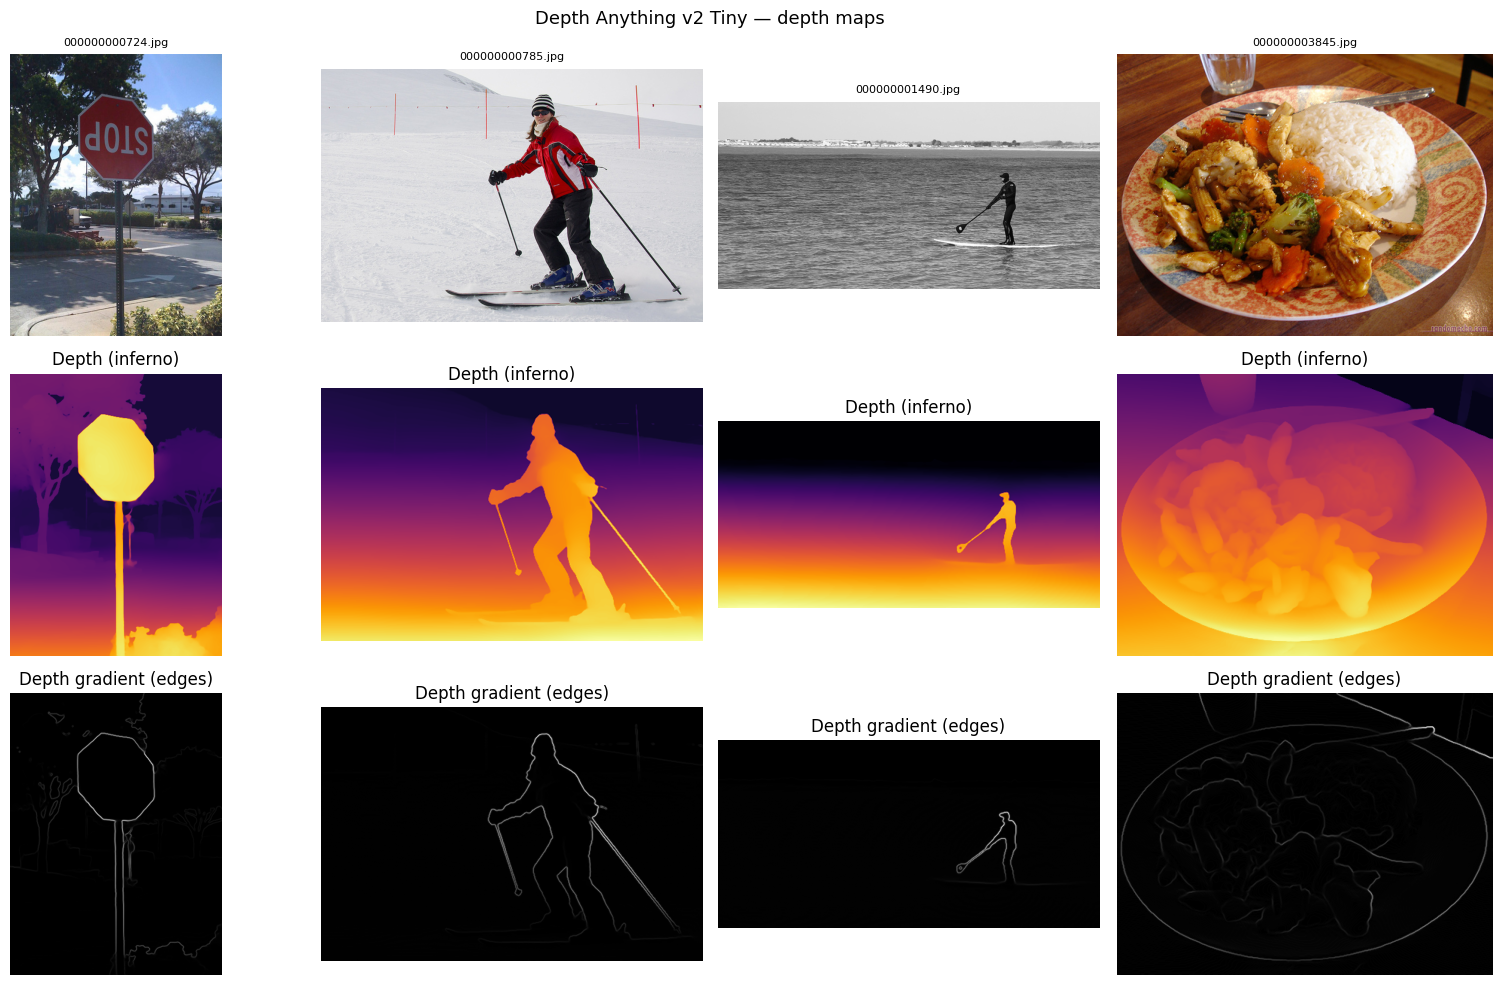

In [6]:
def predict_depth(img_path):
    """Return (PIL image, depth np.array normalised 0-1)."""
    img    = Image.open(img_path).convert("RGB")
    result = depth_pipe(img)
    depth  = np.array(result["depth"])
    depth  = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
    return img, depth


# ── Demo on 4 images ─────────────────────────────────────────────────────────
demo_paths = img_paths[:4]

fig, axes = plt.subplots(3, len(demo_paths), figsize=(4*len(demo_paths), 10))

for col, path in enumerate(demo_paths):
    img, depth = predict_depth(path)

    axes[0, col].imshow(img)
    axes[0, col].set_title(path.name[:16], fontsize=8)
    axes[0, col].axis("off")

    # Depth with colormap
    axes[1, col].imshow(depth, cmap="inferno")
    axes[1, col].set_title("Depth (inferno)")
    axes[1, col].axis("off")

    # Edge-like: gradient of depth
    gx = np.gradient(depth, axis=1)
    gy = np.gradient(depth, axis=0)
    grad = np.sqrt(gx**2 + gy**2)
    axes[2, col].imshow(grad, cmap="gray")
    axes[2, col].set_title("Depth gradient (edges)")
    axes[2, col].axis("off")

plt.suptitle("Depth Anything v2 Tiny — depth maps", fontsize=13)
plt.tight_layout(); plt.show()


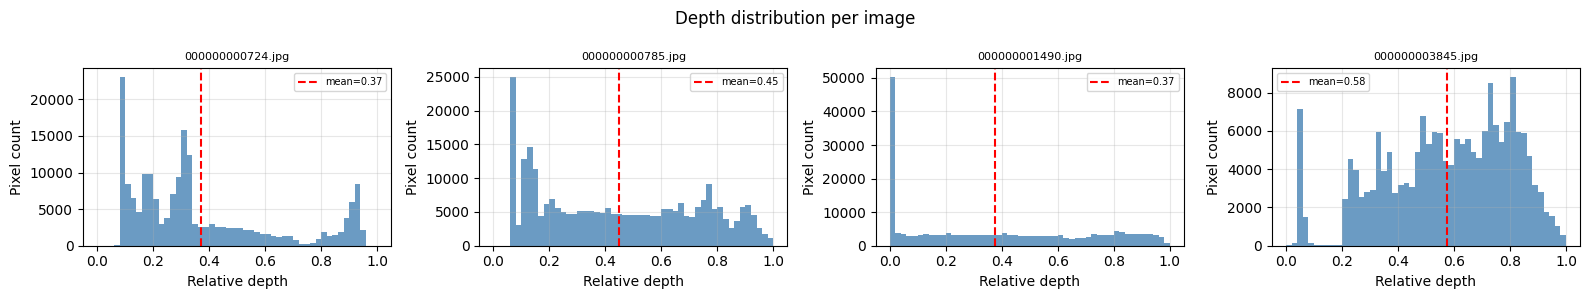

In [7]:
# ── Depth histograms — scene analysis ────────────────────────────────────────
# Compare depth distribution: indoor vs outdoor images

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, path in zip(axes, img_paths[:4]):
    _, depth = predict_depth(path)
    ax.hist(depth.ravel(), bins=50, color="steelblue", alpha=0.8)
    ax.set_title(path.name[:16], fontsize=8)
    ax.set_xlabel("Relative depth"); ax.set_ylabel("Pixel count")
    ax.axvline(depth.mean(), color="red", linestyle="--",
               label=f"mean={depth.mean():.2f}")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Depth distribution per image", fontsize=12)
plt.tight_layout(); plt.show()


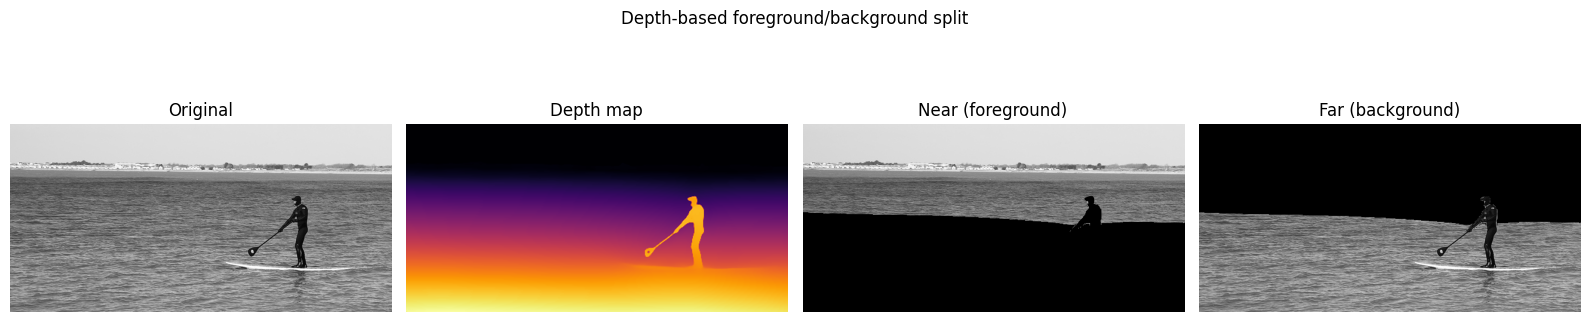

In [8]:
# ── Foreground / background segmentation from depth ──────────────────────────
# Simple trick: threshold depth map at median → near vs far

img, depth = predict_depth(img_paths[2])
threshold  = np.median(depth)

near_mask = depth < threshold   # foreground
far_mask  = depth >= threshold  # background

img_arr = np.array(img)
fg = img_arr.copy(); fg[~near_mask] = 0
bg = img_arr.copy(); bg[~far_mask]  = 0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (im, title) in zip(axes, [
    (img_arr, "Original"),
    (depth,   "Depth map"),
    (fg,      "Near (foreground)"),
    (bg,      "Far (background)"),
]):
    ax.imshow(im, cmap="inferno" if im.ndim == 2 else None)
    ax.set_title(title); ax.axis("off")

plt.suptitle("Depth-based foreground/background split", fontsize=12)
plt.tight_layout(); plt.show()


---
## 🦕 Part 2. DINOv3 — Self-Supervised Features & Auto-Segmentation

**DINOv3** (Meta, August 2025) is a self-supervised Vision Transformer trained
on **1.7 billion images** without any human labels.

### Key insight:
DINOv3's patch-level features carry **semantic meaning** — patches belonging
to the same object cluster together in feature space. We exploit this for
**unsupervised segmentation**: no masks, no labels needed.

### Pipeline:
```
Image (H×W×3)
  ↓  Patchify (16×16 px patches)
  ↓  DINOv3 ViT-Small encoder  (frozen)
  ↓  Patch feature matrix  (N_patches × 384)
  ↓  PCA → 3 components (for visualisation)
  ↓  K-Means clustering (k=5)
  ↓  Pseudo-segmentation map
```

We use the **DINOv2-small** checkpoint from HuggingFace as a CPU-friendly
proxy — DINOv3 small weights will be available as the community uploads them.


In [9]:
from transformers import AutoModel, AutoProcessor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans

print("Loading DINOv3-small (via DINOv2-small weights) …")
dino_model = AutoModel.from_pretrained(
    "facebook/dinov2-small",   # swap for dinov3-small when available on HF
    add_pooling_layer = False,
).to(DEVICE).eval()

dino_proc = AutoProcessor.from_pretrained("facebook/dinov2-small")
PATCH_SIZE = 14    # DINOv2/v3 small uses 14-px patches
print("✅ DINOv3 loaded  |  hidden dim:", dino_model.config.hidden_size)


Loading DINOv3-small (via DINOv2-small weights) …


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

TypeError: Dinov2Model.__init__() got an unexpected keyword argument 'add_pooling_layer'

In [ ]:
@torch.no_grad()
def extract_patch_features(img_path, target_size=448):
    """
    Returns patch feature matrix of shape (n_patches, hidden_dim).
    Also returns (h_patches, w_patches) for reshaping.
    """
    img    = Image.open(img_path).convert("RGB").resize((target_size, target_size))
    inputs = dino_proc(images=img, return_tensors="pt").to(DEVICE)

    out    = dino_model(**inputs)
    # last_hidden_state: (1, 1+n_patches, hidden)
    # index 0 is [CLS] token → skip it
    feats  = out.last_hidden_state[0, 1:, :].cpu().numpy()  # (n_patches, 384)

    h_p = w_p = target_size // PATCH_SIZE
    return feats, (h_p, w_p), img


# Quick sanity check
feats, (hp, wp), _ = extract_patch_features(img_paths[0])
print(f"Patch grid : {hp}×{wp} = {hp*wp} patches")
print(f"Feature dim: {feats.shape[1]}")
print(f"Matrix shape: {feats.shape}")


In [ ]:
# ── PCA visualisation: what do DINO features "look like"? ───────────────────
def pca_feature_map(feats, h_p, w_p):
    """Project patch features to 3D via PCA → RGB image."""
    pca   = PCA(n_components=3)
    proj  = pca.fit_transform(feats)              # (n_patches, 3)
    # Normalise each channel to [0,1]
    proj  = (proj - proj.min(0)) / (proj.max(0) - proj.min(0) + 1e-8)
    return proj.reshape(h_p, w_p, 3)


fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for col, path in enumerate(img_paths[:4]):
    feats, (hp, wp), img_resized = extract_patch_features(path)
    pca_map = pca_feature_map(feats, hp, wp)

    axes[0, col].imshow(img_resized)
    axes[0, col].set_title(path.name[:16], fontsize=8); axes[0, col].axis("off")

    axes[1, col].imshow(pca_map)
    axes[1, col].set_title("PCA (3 components → RGB)")
    axes[1, col].axis("off")

    # Show only first PCA component as heatmap
    axes[2, col].imshow(pca_map[:,:,0], cmap="RdYlGn")
    axes[2, col].set_title("PCA component 1")
    axes[2, col].axis("off")

plt.suptitle("DINOv3 patch features — PCA visualisation", fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# ── K-Means auto-segmentation ─────────────────────────────────────────────────
def dino_segment(img_path, k=5, target_size=448):
    """
    Unsupervised segmentation via DINOv3 features + K-Means.

    Returns
    -------
    img       : PIL image (resized)
    seg_map   : np.ndarray (h_p, w_p) cluster labels
    feats     : raw patch features
    """
    feats, (hp, wp), img = extract_patch_features(img_path, target_size)

    km  = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    lbl = km.fit_predict(feats)
    seg = lbl.reshape(hp, wp)
    return img, seg, feats


CMAP = plt.cm.get_cmap("tab10", 10)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, path in enumerate(img_paths[:4]):
    img, seg, _ = dino_segment(path, k=5)

    axes[0, col].imshow(img)
    axes[0, col].set_title(path.name[:16], fontsize=8); axes[0, col].axis("off")

    axes[1, col].imshow(seg, cmap=CMAP, vmin=0, vmax=9, interpolation="nearest")
    axes[1, col].set_title(f"K-Means k=5 (no labels!)")
    axes[1, col].axis("off")

plt.suptitle("DINOv3 auto-segmentation — K-Means on patch features", fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# ── Effect of k on segmentation granularity ──────────────────────────────────
path = img_paths[1]
img, _, _ = dino_segment(path, k=2)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")

for ax, k in zip(axes[1:], [2, 3, 5, 8]):
    _, seg, _ = dino_segment(path, k=k)
    ax.imshow(seg, cmap=CMAP, vmin=0, vmax=9, interpolation="nearest")
    ax.set_title(f"k={k} clusters"); ax.axis("off")

plt.suptitle("DINOv3 segmentation: effect of k", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── DINOv3 global features for image similarity ──────────────────────────────
@torch.no_grad()
def extract_cls_feature(img_path, target_size=224):
    """Extract [CLS] token — global image representation."""
    img    = Image.open(img_path).convert("RGB").resize((target_size, target_size))
    inputs = dino_proc(images=img, return_tensors="pt").to(DEVICE)
    out    = dino_model(**inputs)
    cls    = out.last_hidden_state[0, 0, :].cpu()   # [CLS] token
    return F.normalize(cls, dim=0)


print("Extracting DINOv3 global features for 100 images …")
dino_feats  = torch.stack([extract_cls_feature(p) for p in tqdm(img_paths[:100])])
print(f"Feature matrix: {dino_feats.shape}")

# Cosine similarity matrix
sim_matrix = (dino_feats @ dino_feats.T).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(sim_matrix, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Cosine similarity matrix (100 images)")
plt.colorbar(im, ax=axes[0])

# Find most similar pair (excluding diagonal)
np.fill_diagonal(sim_matrix, 0)
idx = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
print(f"\nMost similar pair: images {idx[0]} and {idx[1]}  "
      f"(sim={sim_matrix[idx]:.3f})")

for ax_idx, (ax, i) in enumerate(zip(axes[1].inset_axes(
        [[0,0,0.48,1],[0.52,0,0.48,1]]), idx)):
    ax.imshow(Image.open(img_paths[i])); ax.axis("off")
    ax.set_title(f"Image {i}", fontsize=9)
axes[1].axis("off"); axes[1].set_title("Most similar pair")

plt.tight_layout(); plt.show()


---
## 🎯 Part 3. Grounding DINO — Open-Vocabulary Detection

**Grounding DINO** detects objects described by **free-form text** — no fixed
class list, no training on your categories.

### Architecture:
```
Image  →  Vision backbone (Swin-T)  ─┐
                                      ├─ Cross-modal fusion → Boxes + scores
Text   →  BERT encoder              ─┘
```

### Key difference from YOLO:
| Property | YOLO12 | Grounding DINO |
|:--------:|:------:|:--------------:|
| Classes  | Fixed (COCO 80) | Any text |
| Training | Required for new classes | Zero-shot |
| Speed    | Very fast | Moderate |
| Text     | No | Yes |

We use `grounding-dino-tiny` from HuggingFace Transformers — no custom install.


In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

GDINO_ID = "IDEA-Research/grounding-dino-tiny"

print("Loading Grounding DINO Tiny …")
gdino_proc  = AutoProcessor.from_pretrained(GDINO_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GDINO_ID
).to(DEVICE).eval()
print("✅ Grounding DINO loaded")


In [ ]:
def grounding_dino_detect(img_path, text_labels,
                          box_threshold=0.35, text_threshold=0.25):
    """
    Detect objects described by text_labels list in img_path.

    Parameters
    ----------
    text_labels : list of str   e.g. ['a cat', 'a dog']
    box_threshold  : float      min objectness score
    text_threshold : float      min text-match score

    Returns
    -------
    boxes  : tensor (N, 4) in [x1,y1,x2,y2] pixel coords
    scores : tensor (N,)
    labels : list of str  (one per box)
    img    : PIL Image
    """
    img     = Image.open(img_path).convert("RGB")
    inputs  = gdino_proc(
        images      = img,
        text        = [text_labels],      # list of lists
        return_tensors = "pt",
    ).to(DEVICE)

    with torch.no_grad():
        outputs = gdino_model(**inputs)

    results = gdino_proc.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        box_threshold  = box_threshold,
        text_threshold = text_threshold,
        target_sizes   = [img.size[::-1]],
    )[0]

    return results["boxes"], results["scores"], results["labels"], img


def draw_boxes(img, boxes, scores, labels, title=""):
    """Draw bounding boxes on a copy of img."""
    import matplotlib.patches as patches
    COLORS = plt.cm.Set1.colors

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        x1, y1, x2, y2 = box.tolist()
        color = COLORS[i % len(COLORS)]
        rect  = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"{label} {score:.2f}",
                color="white", fontsize=8,
                bbox=dict(facecolor=color, alpha=0.8, pad=1))
    ax.set_title(title or f"{len(boxes)} detections"); ax.axis("off")
    plt.tight_layout(); plt.show()


In [ ]:
# ── Demo: detect with different text prompts ─────────────────────────────────
sample_img = img_paths[10]

QUERY_SETS = [
    ["a person", "a car", "a traffic light"],
    ["a dog", "a cat", "an animal"],
    ["food", "a plate", "a bottle"],
]

fig, axes = plt.subplots(1, len(QUERY_SETS), figsize=(7*len(QUERY_SETS), 6))

for ax, queries in zip(axes, QUERY_SETS):
    boxes, scores, labels, img = grounding_dino_detect(sample_img, queries)
    ax.imshow(img)
    COLORS = plt.cm.Set1.colors
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        x1,y1,x2,y2 = box.tolist()
        col  = COLORS[i % len(COLORS)]
        rect = mpatches.Rectangle((x1,y1),x2-x1,y2-y1,
                                   linewidth=2, edgecolor=col, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-3, f"{label} {score:.2f}", color="white", fontsize=7,
                bbox=dict(facecolor=col, alpha=0.8, pad=1))
    ax.set_title(f"Query: {queries[:2]}…", fontsize=8)
    ax.axis("off")

plt.suptitle("Grounding DINO: same image, different text prompts", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── Confidence threshold effect ───────────────────────────────────────────────
sample_img = img_paths[5]
queries    = ["a person", "a car", "a bag"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, thresh in zip(axes, [0.15, 0.35, 0.55]):
    boxes, scores, labels, img = grounding_dino_detect(
        sample_img, queries, box_threshold=thresh)
    ax.imshow(img)
    COLORS = plt.cm.Set1.colors
    for i,(box,score,label) in enumerate(zip(boxes,scores,labels)):
        x1,y1,x2,y2 = box.tolist()
        col = COLORS[i%len(COLORS)]
        ax.add_patch(mpatches.Rectangle((x1,y1),x2-x1,y2-y1,
                                         linewidth=2,edgecolor=col,facecolor="none"))
        ax.text(x1,y1-3,f"{label} {score:.2f}",color="white",fontsize=7,
                bbox=dict(facecolor=col,alpha=0.8,pad=1))
    ax.set_title(f"box_threshold={thresh}  → {len(boxes)} boxes")
    ax.axis("off")
plt.suptitle("Effect of confidence threshold", fontsize=12)
plt.tight_layout(); plt.show()


---
## ✂️ Part 4. MobileSAM — Prompted Segmentation

**MobileSAM** is a lightweight variant of SAM (Segment Anything Model)
using a **TinyViT encoder** (~5M params vs SAM's 632M).

### CPU performance:
- SAM ViT-H: ~50 s/image on CPU
- SAM 2 Tiny: ~5 s/image on CPU
- **MobileSAM: ~1–3 s/image on CPU** ✅

### Prompt types:
| Prompt | Description |
|:------:|:------------|
| **Box** | `[x1, y1, x2, y2]` — most reliable |
| Point  | `[x, y]` + label 1/0 |
| Everything | No prompt → segment all |

We use **box prompts** (output from Grounding DINO).


In [ ]:
from ultralytics import SAM

print("Loading MobileSAM …")
mobile_sam = SAM("mobile_sam.pt")
print("✅ MobileSAM loaded")
print(f"   Parameters: {sum(p.numel() for p in mobile_sam.model.parameters()):,}")


In [ ]:
def mobilesam_segment(img_path, boxes_xyxy):
    """
    Segment regions defined by bounding boxes.

    Parameters
    ----------
    img_path   : str or Path
    boxes_xyxy : list of [x1,y1,x2,y2] in pixel coords

    Returns
    -------
    masks : list of np.ndarray (H×W bool)
    """
    if len(boxes_xyxy) == 0:
        return []

    results = mobile_sam(
        str(img_path),
        bboxes = boxes_xyxy,
        device = DEVICE,
        verbose = False,
    )
    masks = []
    if results[0].masks is not None:
        for m in results[0].masks.data:
            masks.append(m.cpu().numpy().astype(bool))
    return masks


def overlay_masks(img_pil, masks, labels=None, alpha=0.45):
    """Overlay segmentation masks on PIL image."""
    img_arr = np.array(img_pil).copy()
    COLORS  = plt.cm.Set1.colors

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img_arr)

    for i, mask in enumerate(masks):
        color = np.array(COLORS[i % len(COLORS)][:3])
        overlay = np.zeros_like(img_arr, dtype=float)
        overlay[mask] = color * 255

        blended = img_arr.copy().astype(float)
        blended[mask] = blended[mask] * (1-alpha) + overlay[mask] * alpha
        ax.imshow(blended.astype(np.uint8), alpha=0.0)  # invisible base

        # Draw mask outline
        from matplotlib.contour import QuadContourSet
        ax.contour(mask.astype(float), levels=[0.5],
                   colors=[COLORS[i % len(COLORS)]], linewidths=1.5)

        if labels:
            ys, xs = np.where(mask)
            if len(xs):
                ax.text(xs.mean(), ys.mean(), labels[i],
                        color="white", fontsize=8, ha="center", va="center",
                        bbox=dict(facecolor=COLORS[i%len(COLORS)], alpha=0.7, pad=1))

    # Final blend of all masks
    combined = img_arr.astype(float).copy()
    for i, mask in enumerate(masks):
        color = np.array(COLORS[i % len(COLORS)][:3])
        combined[mask] = combined[mask] * (1-alpha) + color[None]*255 * alpha
    ax.imshow(combined.astype(np.uint8))
    ax.axis("off")
    return fig, ax


In [ ]:
# ── Demo: SAM segmentation with GT boxes from COCO ───────────────────────────
demo_id   = SUBSET_IDS[3]
demo_path = IMG_DIR / img_meta[demo_id]["file_name"]
demo_anns = ann_by_img[demo_id][:5]   # first 5 annotations

# COCO boxes are [x, y, w, h] → convert to [x1,y1,x2,y2]
gt_boxes = [[a["bbox"][0], a["bbox"][1],
             a["bbox"][0]+a["bbox"][2], a["bbox"][1]+a["bbox"][3]]
            for a in demo_anns]
gt_labels = [id2name[a["category_id"]] for a in demo_anns]

masks = mobilesam_segment(demo_path, gt_boxes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(Image.open(demo_path))
for i,(box,lbl) in enumerate(zip(gt_boxes, gt_labels)):
    x1,y1,x2,y2 = box
    COLORS = plt.cm.Set1.colors
    axes[0].add_patch(mpatches.Rectangle(
        (x1,y1),x2-x1,y2-y1, linewidth=2,
        edgecolor=COLORS[i%len(COLORS)], facecolor="none"))
    axes[0].text(x1,y1-3,lbl,color="white",fontsize=8,
                 bbox=dict(facecolor=COLORS[i%len(COLORS)],alpha=0.8,pad=1))
axes[0].set_title("GT boxes (from COCO)"); axes[0].axis("off")

fig2, ax2 = overlay_masks(Image.open(demo_path), masks, gt_labels)
ax2.set_title(f"MobileSAM masks ({len(masks)} regions)")
plt.show()


In [ ]:
# ── Prompt types: box vs point ────────────────────────────────────────────────
demo_path = img_paths[7]
img_pil   = Image.open(demo_path)
W, H      = img_pil.size
cx, cy    = W//2, H//2

# Box prompt: centre region
box_results = mobile_sam(str(demo_path),
                          bboxes=[[W*0.2, H*0.2, W*0.8, H*0.8]],
                          device=DEVICE, verbose=False)
# Point prompt: image centre
point_results = mobile_sam(str(demo_path),
                             points=[[cx, cy]], labels=[1],
                             device=DEVICE, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_pil); axes[0].set_title("Original"); axes[0].axis("off")

for ax, results, title in zip(axes[1:],
        [box_results, point_results],
        ["Box prompt (centre 60%)", "Point prompt (centre)"]):
    ax.imshow(img_pil)
    if results[0].masks is not None:
        for m in results[0].masks.data[:3]:
            mask = m.cpu().numpy().astype(bool)
            colored = np.zeros((*mask.shape, 4))
            colored[mask] = [0.2, 0.8, 0.4, 0.45]
            ax.imshow(colored)
    ax.set_title(title); ax.axis("off")

plt.suptitle("MobileSAM prompt types", fontsize=12)
plt.tight_layout(); plt.show()


---
## 🔗 Part 5. CLIP — Zero-Shot Classification & Image Retrieval

**CLIP** (Contrastive Language-Image Pre-Training, OpenAI) learns a shared
embedding space for images and text by training on 400M image-text pairs.

### Applications:
1. **Zero-shot classification** — no training data needed
2. **Image retrieval** — find images matching a text query
3. **Re-ranking / verification** — verify a detected object's class

### How similarity works:
```
Image  → Image Encoder → image embedding  (512-d, L2-normalised)
Text   → Text Encoder  → text embedding   (512-d, L2-normalised)
Score  = cosine_similarity(image_emb, text_emb)
```


In [ ]:
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(DEVICE).eval()
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

print("✅ CLIP ViT-B/32 loaded")
print(f"   Image embed dim: {clip_model.visual.output_dim}")


In [ ]:
@torch.no_grad()
def clip_image_embed(img_or_path):
    """Encode a single image. Returns L2-normalised 512-d vector."""
    if isinstance(img_or_path, (str, Path)):
        img = Image.open(img_or_path).convert("RGB")
    else:
        img = img_or_path
    x = clip_preprocess(img).unsqueeze(0).to(DEVICE)
    e = clip_model.encode_image(x)
    return F.normalize(e, dim=-1).squeeze(0).cpu()


@torch.no_grad()
def clip_text_embed(texts):
    """Encode a list of text strings. Returns (N, 512) L2-normalised."""
    tokens = clip_tokenizer(texts).to(DEVICE)
    e = clip_model.encode_text(tokens)
    return F.normalize(e, dim=-1).cpu()


# Zero-shot classification demo
sample_path = img_paths[15]
CLASSES     = ["a dog", "a cat", "a person", "a car",
                "food on a plate", "an airplane", "a bicycle"]

img_e  = clip_image_embed(sample_path)
text_e = clip_text_embed(CLASSES)
sims   = (img_e @ text_e.T).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(Image.open(sample_path)); axes[0].axis("off")

sorted_idx = np.argsort(sims)[::-1]
bars = axes[1].barh([CLASSES[i] for i in sorted_idx],
                     [sims[i] for i in sorted_idx],
                     color="steelblue", alpha=0.8)
axes[1].set_xlabel("CLIP cosine similarity")
axes[1].set_title("Zero-shot class scores")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("CLIP zero-shot classification", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── Build CLIP index for 200 images ──────────────────────────────────────────
print("Building CLIP image index (200 images) …")
clip_index_paths = img_paths[:200]
clip_embeddings  = torch.stack([
    clip_image_embed(p) for p in tqdm(clip_index_paths)
])  # (200, 512)
print(f"Index shape: {clip_embeddings.shape}")


In [ ]:
def text_to_image_retrieval(query_text, top_k=5):
    """Retrieve top-K images matching a text query."""
    q_emb  = clip_text_embed([query_text])          # (1, 512)
    sims   = (q_emb @ clip_embeddings.T).squeeze()  # (200,)
    topk   = sims.topk(top_k)
    return topk.indices.tolist(), topk.values.tolist()


# ── Demo queries ──────────────────────────────────────────────────────────────
QUERIES = [
    "a dog running outside",
    "people eating food at a table",
    "a red vehicle on a street",
    "an animal in the wild",
]

fig, axes = plt.subplots(len(QUERIES), 6, figsize=(18, 3*len(QUERIES)))

for row, query in enumerate(QUERIES):
    indices, scores = text_to_image_retrieval(query, top_k=5)
    axes[row, 0].text(0.5, 0.5, f'"{query}"',
                       transform=axes[row,0].transAxes,
                       ha="center", va="center", fontsize=9,
                       wrap=True)
    axes[row, 0].axis("off")
    for col, (idx, score) in enumerate(zip(indices, scores), start=1):
        axes[row, col].imshow(Image.open(clip_index_paths[idx]))
        axes[row, col].set_title(f"sim={score:.3f}", fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("CLIP text-to-image retrieval", fontsize=13)
plt.tight_layout(); plt.show()


---
## 🔗 Part 6. Full Pipeline: Grounding DINO → MobileSAM → CLIP

We chain all three models into a **production-ready pipeline**:

```
User query: "find all dogs and verify"
     │
     ▼
[Grounding DINO]  text="a dog" → bounding boxes + scores
     │
     ▼
[MobileSAM]       boxes → pixel-level masks
     │
     ▼
[CLIP]            crop each masked region → re-score with CLIP
     │
     ▼
Final detections: boxes + masks + verified CLIP confidence
```

### Why chain CLIP at the end?
Grounding DINO is fast but can produce false positives.
CLIP re-ranks the detections using a **different visual representation**
— catching errors that Grounding DINO misses.


In [ ]:
def full_pipeline(img_path, text_query,
                  gdino_thresh=0.30, clip_verify_thresh=0.18,
                  verbose=True):
    """
    End-to-end pipeline: Grounding DINO → MobileSAM → CLIP.

    Returns
    -------
    results : list of dicts with keys:
        box, gdino_score, mask, clip_score, label, kept
    """
    img = Image.open(img_path).convert("RGB")

    # ── Step 1: Grounding DINO detection ─────────────────────────────────────
    queries = [text_query] if isinstance(text_query, str) else text_query
    boxes, gdino_scores, gdino_labels, _ = grounding_dino_detect(
        img_path, queries, box_threshold=gdino_thresh)

    if verbose:
        print(f"Step 1 — Grounding DINO: {len(boxes)} detections")

    if len(boxes) == 0:
        return []

    # ── Step 2: MobileSAM segmentation ───────────────────────────────────────
    masks = mobilesam_segment(img_path, boxes.tolist())
    if verbose:
        print(f"Step 2 — MobileSAM: {len(masks)} masks")

    # ── Step 3: CLIP verification ─────────────────────────────────────────────
    text_pos = [f"a photo of {text_query}"] if isinstance(text_query, str)                else [f"a photo of {q}" for q in text_query]
    text_neg = ["background", "an empty scene", "irrelevant object"]
    all_texts = text_pos + text_neg
    text_embs = clip_text_embed(all_texts)   # (n_texts, 512)

    results = []
    W, H    = img.size
    for i, (box, g_score, g_label) in enumerate(
            zip(boxes.tolist(), gdino_scores.tolist(), gdino_labels)):
        x1, y1, x2, y2 = [max(0, int(v)) for v in box]
        x2 = min(x2, W); y2 = min(y2, H)

        # Crop detected region
        crop = img.crop((x1, y1, x2, y2))
        if crop.size[0] < 5 or crop.size[1] < 5:
            continue

        crop_emb   = clip_image_embed(crop)                    # (512,)
        clip_sims  = (crop_emb @ text_embs.T).numpy()         # (n_texts,)
        clip_score = float(clip_sims[:len(text_pos)].max())   # best positive
        neg_score  = float(clip_sims[len(text_pos):].max())   # best negative

        kept = clip_score > clip_verify_thresh and clip_score > neg_score

        results.append({
            "box":          box,
            "gdino_score":  g_score,
            "mask":         masks[i] if i < len(masks) else None,
            "clip_score":   clip_score,
            "label":        g_label,
            "kept":         kept,
        })

    if verbose:
        n_kept = sum(r["kept"] for r in results)
        print(f"Step 3 — CLIP verify: {n_kept}/{len(results)} kept")

    return results


In [ ]:
# ── Run pipeline on 3 images ─────────────────────────────────────────────────
PIPELINE_QUERY = "a person"

pipeline_demos = [img_paths[i] for i in [0, 5, 20]]

for path in pipeline_demos:
    print(f"\n{'='*50}")
    print(f"Image: {path.name}")
    results = full_pipeline(path, PIPELINE_QUERY, verbose=True)

    img = Image.open(path)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")

    # After Grounding DINO
    axes[1].imshow(img)
    for r in results:
        x1,y1,x2,y2 = r["box"]
        col = "#2ecc71" if r["kept"] else "#e74c3c"
        axes[1].add_patch(mpatches.Rectangle(
            (x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=col, facecolor="none"))
        axes[1].text(x1, y1-3,
                     f"{r['label']} g={r['gdino_score']:.2f}",
                     color="white", fontsize=7,
                     bbox=dict(facecolor=col, alpha=0.8, pad=1))
    axes[1].set_title(f"Grounding DINO ({len(results)} dets)")
    axes[1].axis("off")

    # After CLIP verification + masks
    img_arr = np.array(img).astype(float)
    axes[2].imshow(img)
    COLORS = plt.cm.Set1.colors
    kept_count = 0
    for i, r in enumerate(results):
        if not r["kept"]: continue
        x1,y1,x2,y2 = r["box"]
        col = COLORS[kept_count % len(COLORS)]
        axes[2].add_patch(mpatches.Rectangle(
            (x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=col, facecolor="none"))
        axes[2].text(x1, y1-3,
                     f"c={r['clip_score']:.2f}",
                     color="white", fontsize=7,
                     bbox=dict(facecolor=col, alpha=0.8, pad=1))
        if r["mask"] is not None:
            colored = np.zeros((*r["mask"].shape, 4))
            colored[r["mask"]] = [*col[:3], 0.4]
            axes[2].imshow(colored)
        kept_count += 1
    axes[2].set_title(f"After CLIP ({kept_count} verified)")
    axes[2].axis("off")

    plt.suptitle(f'Query: "{PIPELINE_QUERY}" — {path.name}', fontsize=11)
    plt.tight_layout(); plt.show()


In [ ]:
# ── Score comparison: Grounding DINO vs CLIP ──────────────────────────────────
# Collect scores from multiple images
all_gdino = []; all_clip = []; all_kept = []

for path in img_paths[:30]:
    res = full_pipeline(path, "a person", verbose=False)
    for r in res:
        all_gdino.append(r["gdino_score"])
        all_clip.append(r["clip_score"])
        all_kept.append(r["kept"])

all_gdino = np.array(all_gdino)
all_clip  = np.array(all_clip)
all_kept  = np.array(all_kept)

if len(all_gdino):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter: gDINO score vs CLIP score
    axes[0].scatter(all_gdino[all_kept],  all_clip[all_kept],
                    c="#2ecc71", alpha=0.7, label="kept", s=40)
    axes[0].scatter(all_gdino[~all_kept], all_clip[~all_kept],
                    c="#e74c3c", alpha=0.5, label="rejected", s=40)
    axes[0].set_xlabel("Grounding DINO score")
    axes[0].set_ylabel("CLIP score")
    axes[0].set_title("gDINO score vs CLIP score")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram
    for scores, label, color in [
        (all_gdino, "Grounding DINO", "steelblue"),
        (all_clip,  "CLIP",           "coral"),
    ]:
        axes[1].hist(scores, bins=20, alpha=0.6, label=label, color=color)
    axes[1].set_title("Score distributions")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"Kept: {all_kept.sum()}/{len(all_kept)}  "
          f"({100*all_kept.mean():.0f}% pass CLIP verification)")


---
## 🏆 Part 7. Kaggle — Object Retrieval (Recall@K)

### Task
Given a **text query**, retrieve the top-K most relevant images from a gallery.

### Metric: Recall@K
$$\text{Recall@K} = \frac{|\text{relevant images in top-K}|}{|\text{all relevant images}|}$$

A retrieved image is **relevant** if it contains at least one instance of
the queried category (according to COCO ground truth).

### Submission format
```json
[
  {"query": "a dog",   "retrieved": ["img001", "img003", "img007", ...]},
  {"query": "a person","retrieved": ["img002", "img004", "img006", ...]},
  ...
]
```


In [ ]:
# ── Build full CLIP index for all available images ────────────────────────────
print("Building CLIP index …")
ALL_PATHS = img_paths  # all downloaded images
if len(clip_index_paths) < len(ALL_PATHS):
    clip_index_paths = ALL_PATHS
    clip_embeddings  = torch.stack([
        clip_image_embed(p) for p in tqdm(ALL_PATHS)
    ])
print(f"Index: {clip_embeddings.shape}")


In [ ]:
def retrieve(query_text, top_k=10):
    """CLIP text-to-image retrieval. Returns list of image file stems."""
    q_emb    = clip_text_embed([query_text])
    sims     = (q_emb @ clip_embeddings.T).squeeze()
    topk_idx = sims.topk(top_k).indices.tolist()
    return [clip_index_paths[i].stem for i in topk_idx]


def recall_at_k(query_category, retrieved_stems, k=5):
    """
    Compute Recall@K against COCO ground truth.
    retrieved_stems : list of file stems (first k used)
    """
    retrieved_k = set(retrieved_stems[:k])

    # Find COCO image ids that contain query_category
    cat_ids = [cid for cid, name in id2name.items()
               if query_category.lower() in name.lower()]
    relevant_ids = set()
    for iid in SUBSET_IDS:
        for ann in ann_by_img[iid]:
            if ann["category_id"] in cat_ids:
                stem = img_meta[iid]["file_name"].replace(".jpg","")
                relevant_ids.add(stem)
                break

    if not relevant_ids:
        return 0.0, 0

    hits = len(retrieved_k & relevant_ids)
    return hits / min(k, len(relevant_ids)), len(relevant_ids)


In [ ]:
# ── Evaluate on COCO categories ───────────────────────────────────────────────
EVAL_QUERIES = [
    ("a dog",      "dog"),
    ("a cat",      "cat"),
    ("a person",   "person"),
    ("a car",      "car"),
    ("a bicycle",  "bicycle"),
]

K_VALUES = [1, 5, 10]
results_recall = {k: [] for k in K_VALUES}

print(f"{'Query':20s}  {'N_rel':>5s}  " +
      "  ".join(f"R@{k}" for k in K_VALUES))
print("-" * 55)

for query_text, category in EVAL_QUERIES:
    retrieved = retrieve(query_text, top_k=max(K_VALUES))
    row = [f"{query_text:20s}"]
    _, n_rel = recall_at_k(category, retrieved, k=K_VALUES[0])
    row.append(f"{n_rel:>5d}")
    for k in K_VALUES:
        r, _ = recall_at_k(category, retrieved, k=k)
        results_recall[k].append(r)
        row.append(f"{r:.2f}   ")
    print("  ".join(row))

print("-" * 55)
for k in K_VALUES:
    print(f"Mean Recall@{k}: {np.mean(results_recall[k]):.3f}")


In [ ]:
# ── Generate Kaggle submission ────────────────────────────────────────────────
SUBMISSION_QUERIES = [
    "a dog", "a cat", "a person", "a car",
    "a bicycle", "food on a plate", "a bird", "a horse",
]

submission = []
for q in SUBMISSION_QUERIES:
    retrieved = retrieve(q, top_k=10)
    submission.append({"query": q, "retrieved": retrieved})

with open("submission_retrieval.json", "w") as f:
    json.dump(submission, f, indent=2)

print("✅ Submission saved: submission_retrieval.json")
print(f"   Queries: {len(submission)}")
print(f"\nPreview:")
for s in submission[:3]:
    print(f"  '{s['query']}' → {s['retrieved'][:3]} …")


---
## 📝 Exercises

### Exercise 1 — Depth + Segmentation fusion

Use Depth Anything output to **filter** DINOv3 K-Means segments:
keep only clusters that are predominantly in the **foreground** (near depth).

```python
def depth_guided_segment(img_path, k=5, near_fraction_threshold=0.4):
    """
    Run DINOv3 K-Means, then discard clusters where less than
    near_fraction_threshold of pixels are in the near depth zone.
    """
    img, seg, _ = dino_segment(img_path, k=k)
    _, depth    = predict_depth(img_path)
    # TODO: resize depth to match seg grid, filter clusters
    pass
```

**Expected result:** foreground objects better isolated from background.


In [ ]:
# TODO: implement depth_guided_segment

def depth_guided_segment(img_path, k=5, near_fraction_threshold=0.4):
    from skimage.transform import resize as sk_resize

    img, seg, _ = dino_segment(img_path, k=k)
    _, depth    = predict_depth(img_path)

    # Step 1: resize depth to seg grid (hp × wp)
    depth_small = sk_resize(depth, seg.shape, anti_aliasing=True)

    near_mask   = depth_small < np.median(depth_small)

    # Step 2: for each cluster, compute fraction of near pixels
    seg_filtered = seg.copy()
    for cluster_id in range(k):
        cluster_mask   = seg == cluster_id
        near_fraction  = (cluster_mask & near_mask).sum() / (cluster_mask.sum() + 1e-8)
        if near_fraction < near_fraction_threshold:
            seg_filtered[cluster_mask] = -1   # mark as background

    return img, seg, seg_filtered


# Test
path = img_paths[3]
img, seg_orig, seg_filtered = depth_guided_segment(path, k=5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(seg_orig, cmap=CMAP, vmin=0, vmax=9); axes[1].set_title("DINOv3 K-Means"); axes[1].axis("off")
axes[2].imshow(seg_filtered, cmap=CMAP, vmin=-1, vmax=9); axes[2].set_title("Depth-filtered"); axes[2].axis("off")
plt.tight_layout(); plt.show()


### Exercise 2 — CLIP Re-ranking

The pipeline currently uses Grounding DINO scores for the final ordering.
Implement **re-ranking by CLIP score** and compare Recall@5 before/after.

```python
def pipeline_with_clip_reranking(img_path, query, top_k=5):
    results = full_pipeline(img_path, query, verbose=False)
    # TODO: sort results by clip_score descending, return top_k
    pass
```


In [ ]:
# TODO: implement and evaluate CLIP re-ranking

def pipeline_with_clip_reranking(img_path, query, top_k=5):
    results = full_pipeline(img_path, query, verbose=False)
    # Sort by CLIP score
    results_sorted = sorted(results, key=lambda r: r["clip_score"], reverse=True)
    return results_sorted[:top_k]


# Quick test
sample_res = pipeline_with_clip_reranking(img_paths[0], "a person")
print(f"Top detections by CLIP score:")
for r in sample_res:
    print(f"  {r['label']:15s}  gDINO={r['gdino_score']:.3f}  CLIP={r['clip_score']:.3f}")


### Exercise 3 — Retrieval Recall Comparison

Compare **three retrieval strategies** on the same queries:
1. CLIP embeddings (current)
2. DINOv3 CLS token embeddings
3. Combined: `0.5 * CLIP + 0.5 * DINOv3`

Which gives the best Recall@5?


In [ ]:
# TODO: compare retrieval strategies

# Strategy 1: CLIP — already built (clip_embeddings)
# Strategy 2: DINOv3 — already built (dino_feats for first 100 images)
# Strategy 3: combine

# Hint: make sure both embedding sets are on the same set of images
# then compute sims for each and compare recall@5

# def retrieve_with_embeddings(query_text, embeddings, paths, top_k=10):
#     q_emb = clip_text_embed([query_text])
#     sims  = (q_emb @ embeddings.T).squeeze()
#     idx   = sims.topk(top_k).indices.tolist()
#     return [paths[i].stem for i in idx]

# evaluate and print comparison table
print("TODO: implement and compare strategies")


---
## 📋 Summary

### Models used today:

| Model | Architecture | Params | Task | Key idea |
|:-----:|:------------:|:------:|:----:|:--------:|
| **Depth Anything v2 Tiny** | DPT + ViT-S | 25M | Depth estimation | Dense prediction from single image |
| **DINOv3-Small** | ViT-S | 22M | Feature extraction | SSL on 1.7B images, no labels |
| **Grounding DINO** | Swin-T + BERT | 172M | Open-vocab detection | Vision-language fusion |
| **MobileSAM** | TinyViT + decoder | 9.6M | Prompted segmentation | Distilled from SAM |
| **CLIP ViT-B/32** | ViT-B + transformer | 151M | Retrieval / verification | Contrastive image-text pretraining |

### Key lessons:

**1. Foundation models = frozen features + lightweight heads**
We never updated any weights — all power came from pre-training.

**2. Chaining models creates new capabilities**
Grounding DINO alone gives boxes. MobileSAM alone needs prompts.
Together → open-vocabulary segmentation.

**3. CLIP as a verifier**
Different training objectives (contrastive vs detection) = complementary errors.
CLIP catches false positives that Grounding DINO misses.

**4. CPU is viable for prototyping**
| Model | CPU time/image |
|:-----:|:--------------:|
| Depth Anything v2 Tiny | ~1 s |
| DINOv3-Small | ~0.5 s |
| Grounding DINO Tiny | ~3 s |
| MobileSAM | ~2 s |
| CLIP ViT-B/32 | ~0.1 s |

### Further reading:
- [Depth Anything v2 paper](https://arxiv.org/abs/2406.09414)
- [DINOv3 technical report](https://arxiv.org/abs/2508.10104)
- [Grounding DINO paper](https://arxiv.org/abs/2303.05499)
- [MobileSAM paper](https://arxiv.org/abs/2306.14289)
- [CLIP paper](https://arxiv.org/abs/2103.00020)
